## Etsy.com

Etsy is the global marketplace for unique and creative goods. It’s home to a universe of special, extraordinary items, from unique handcrafted pieces to vintage treasures. Etsy operates two-sided online marketplaces that collectively connect nearly 100 million passionate and creative buyers and 7.7 million sellers around the world.

Buyers come to the Etsy marketplace for meaningful, one-of-a-kind items handcrafted and curated with passion and expertise by our creative entrepreneurs. We are focused on attracting potential buyers to Etsy for everyday items that have meaning and those “special” purchase occasions that happen throughout the year. These include items that reflect an individual’s unique style; gifting that demonstrates thought and care; and celebrations that express creativity and fun.

On Etsy, someone searches for …
- Wall art every two seconds
- Wedding-related items every two seconds
- Gift-related items every second
- Antique or vintage items every half a second

## Challenge

Etsy has nearly 100 Million active listings on the etsy.com marketplace for sale from more than 5 million active sellers. You are provided a subset of those products as the training data.

The task is to leverage the training dataset to learn patterns from and to predict the following attributes on an unseen test dataset given a products’ information:

- top category id
- bottom category id

The goal is to maximize F1 for each of the classes on each attribute to predict (top category, bottom category). Your approaches and models will be benchmarked against a hidden test dataset.

Bonus points will be given for submissions that:

- visualize some learned representations or embeddings and show that similar items cluster together
- compares the performance of pre-trained embeddings taken from hubs or papers with a fine-tuned model


## Getting Started

Here is some sample code to get you started on the challenge!

Happy Hacking!

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# libraries
import io
import os
from datetime import datetime
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from sklearn import metrics

# Matplotlib configuration
font = { 'family': 'DejaVu Sans', 'weight': 'bold', 'size': 16 }
plt.rc('font', **font)


In [3]:
# set random seed
np.random.seed(seed=42)

## Dataset

The train and test datasets are shared in **parquet** format.

In order to download the dataset, please sign the NDA first.

In [4]:
PATH = f"/content/drive/MyDrive/data/data/data_2025/2025"

In [5]:
!ls {PATH}

test  train  Untitled.ipynb


In [6]:
#parquet_filenames_train = !ls {PATH}/train
#parquet_filenames_train = list(parquet_filenames_train)

import os

parquet_filenames_train = os.listdir(f"{PATH}/train")

print(parquet_filenames_train)

['part-00003-of-00362.parquet.parquet', 'part-00007-of-00362.parquet.parquet', 'part-00009-of-00362.parquet.parquet', 'part-00004-of-00362.parquet.parquet', 'part-00001-of-00362.parquet.parquet', 'part-00002-of-00362.parquet.parquet', 'part-00000-of-00362.parquet.parquet', 'part-00011-of-00362.parquet.parquet', 'part-00010-of-00362.parquet.parquet', 'part-00006-of-00362.parquet.parquet', 'part-00012-of-00362.parquet.parquet', 'part-00008-of-00362.parquet.parquet', 'part-00005-of-00362.parquet.parquet', 'part-00025-of-00362.parquet.parquet', 'part-00021-of-00362.parquet.parquet', 'part-00016-of-00362.parquet.parquet', 'part-00023-of-00362.parquet.parquet', 'part-00015-of-00362.parquet.parquet', 'part-00024-of-00362.parquet.parquet', 'part-00020-of-00362.parquet.parquet', 'part-00022-of-00362.parquet.parquet', 'part-00017-of-00362.parquet.parquet', 'part-00013-of-00362.parquet.parquet', 'part-00019-of-00362.parquet.parquet', 'part-00014-of-00362.parquet.parquet', 'part-00018-of-00362.par

In [7]:
parquet_filenames_train[:3]

['part-00003-of-00362.parquet.parquet',
 'part-00007-of-00362.parquet.parquet',
 'part-00009-of-00362.parquet.parquet']

In [8]:
f"Number of files in train: {len(parquet_filenames_train):,}"

'Number of files in train: 362'

In [9]:
import os

parquet_filenames_test = os.listdir(f"{PATH}/test")
#parquet_filenames_test = !ls {PATH}/test

In [10]:
parquet_filenames_test[:3]

['part-00013-of-00362.parquet.parquet',
 'part-00010-of-00362.parquet.parquet',
 'part-00001-of-00362.parquet.parquet']

In [11]:
f"Number of files in test: {len(parquet_filenames_test):,}"

'Number of files in test: 362'

## Exploratory Data Analysis

It is important to familiarize yourself with the dataset by using measures of centrality (e.g. mean) and statistical dispersion (e.g. variance) and data visualization methods. The following is just some Pandas preprocessing and Matplotlib visualizations to get you started. Feel free to explore the data much further and come up with ideas that might help you in the task!

### Training Dataset

This dataset can be used to train models and learn patterns from.

In [9]:
def read_data(folder, filenames):
    """ Read parquet data from mutiple files """

    dataframes = [
        pd.read_parquet(f"{PATH}/{folder}/{filename}")
        for filename in filenames
    ]

    return pd.concat(dataframes)

In [10]:
df_train = read_data("train", parquet_filenames_train)
print(df_train)

    product_id                                              title  \
0   1600236823  Mid Century White Space Age Witch Hat Pendant ...   
1    878089377  Double suspension NILS Decorative luminaires i...   
2   1077464801  Rare Opal Glass Pendant by Nordisk Solar, dani...   
3   1565415785  Hanging lamp from the headlight of an old Sovi...   
4    212112156            White domed ceramic pendant light shade   
..         ...                                                ...   
87  1462383418  Stunning Antique Victorian Silver Cranberry ov...   
88  1569171978  Vintage Waterford Crystal Perfume Atomizer Art...   
89  1552981825  Fine Silver Novelty Miniature Glass Bird Perfu...   
90  1533241809  Antique 1800s Sterling Silver Scent Bottle w/ ...   
91   840850289  Vintage Perfume Glass  Hand painted enamel Ros...   

                                          description  \
0   Classic white mid century &#39;witch hat&#39; ...   
1   Original creation KAUZE LUMINAIRES\n\nLet your...   


In [16]:
f"Number of rows in train: {len(df_train):,}"

'Number of rows in train: 229,624'

In [15]:
f"Number of unique products in train: {len(df_train['product_id'].unique()):,}"

'Number of unique products in train: 229,624'

In [17]:
f"Number of columns in train: {len(df_train.columns):,}"

'Number of columns in train: 23'

In [18]:
list(df_train.columns)

['product_id',
 'title',
 'description',
 'tags',
 'type',
 'room',
 'craft_type',
 'recipient',
 'material',
 'occasion',
 'holiday',
 'art_subject',
 'style',
 'shape',
 'pattern',
 'bottom_category_id',
 'bottom_category_text',
 'top_category_id',
 'top_category_text',
 'primary_color_id',
 'primary_color_text',
 'secondary_color_id',
 'secondary_color_text']

In [19]:
df_train.dtypes

,0
product_id,int64
title,object
description,object
tags,object
type,object
room,object
craft_type,object
recipient,object
material,object
occasion,object


In [20]:
df_train.iloc[0]


,0
product_id,1600236823
title,Mid Century White Space Age Witch Hat Pendant ...
description,Classic white mid century &#39;witch hat&#39; ...
tags,"witch hat lamp,dijkstra lamp,fog morup,guzzini..."
type,physical
room,
craft_type,
recipient,
material,plastic
occasion,


In [21]:
df_train.head(2)

,product_id,title,description,tags,type,room,craft_type,recipient,material,occasion,...,shape,pattern,bottom_category_id,bottom_category_text,top_category_id,top_category_text,primary_color_id,primary_color_text,secondary_color_id,secondary_color_text
0,1600236823,Mid Century White Space Age Witch Hat Pendant ...,Classic white mid century &#39;witch hat&#39; ...,"witch hat lamp,dijkstra lamp,fog morup,guzzini...",physical,,,,plastic,,...,,,2196,home_and_living.lighting.light_fixtures.ceilin...,8,home_and_living,17,white,0,beige
1,878089377,Double suspension NILS Decorative luminaires i...,Original creation KAUZE LUMINAIRES\n\nLet your...,,physical,kitchen & dining,,,fabric,,...,,,2196,home_and_living.lighting.light_fixtures.ceilin...,8,home_and_living,1,black,0,beige


In [12]:
df_train['type'].unique()

array(['physical', 'download', ''], dtype=object)

In [13]:
df_train['type'].value_counts(dropna=False)

,count
type,
physical,218568
download,10708
,348


In [24]:
f"Number of top categories in train: {len(df_train['top_category_text'].unique()):,}"

'Number of top categories in train: 15'

In [25]:
pd.value_counts(df_train['top_category_text'], sort=True, ascending=False)

<ipython-input-25-32be510a6e5e>:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(df_train['top_category_text'], sort=True, ascending=False)


,count
top_category_text,
home_and_living,54600
craft_supplies_and_tools,33393
clothing,30143
toys_and_games,13835
accessories,12416
paper_and_party_supplies,12207
bath_and_beauty,11327
weddings,10143
shoes,8892


In [25]:
f"Number of bottom categories in train: {len(df_train['bottom_category_text'].unique()):,}"

'Number of bottom categories in train: 2,609'

In [26]:
pd.value_counts(df_train['bottom_category_text'], sort=True, ascending=False)

<ipython-input-26-473de05b9c24>:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(df_train['bottom_category_text'], sort=True, ascending=False)


,count
bottom_category_text,
accessories.scarves_and_wraps.scarves,98
toys_and_games.sports_and_outdoor_games.martial_arts_and_boxing.boxing_gloves,98
art_and_collectibles.drawing_and_illustration.architectural_drawings,98
jewelry.earrings.dangle_earrings.chandbalis,98
craft_supplies_and_tools.closures_and_fasteners.buttons,98
...,...
home_and_living.furniture.entryway_furniture.standing_coat_racks,44
clothing.girls_clothing.baby_girls_clothing.socks_and_leg_warmers,44
home_and_living.lighting.light_accessories,43


<ipython-input-27-f28fe1f4d405>:8: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(


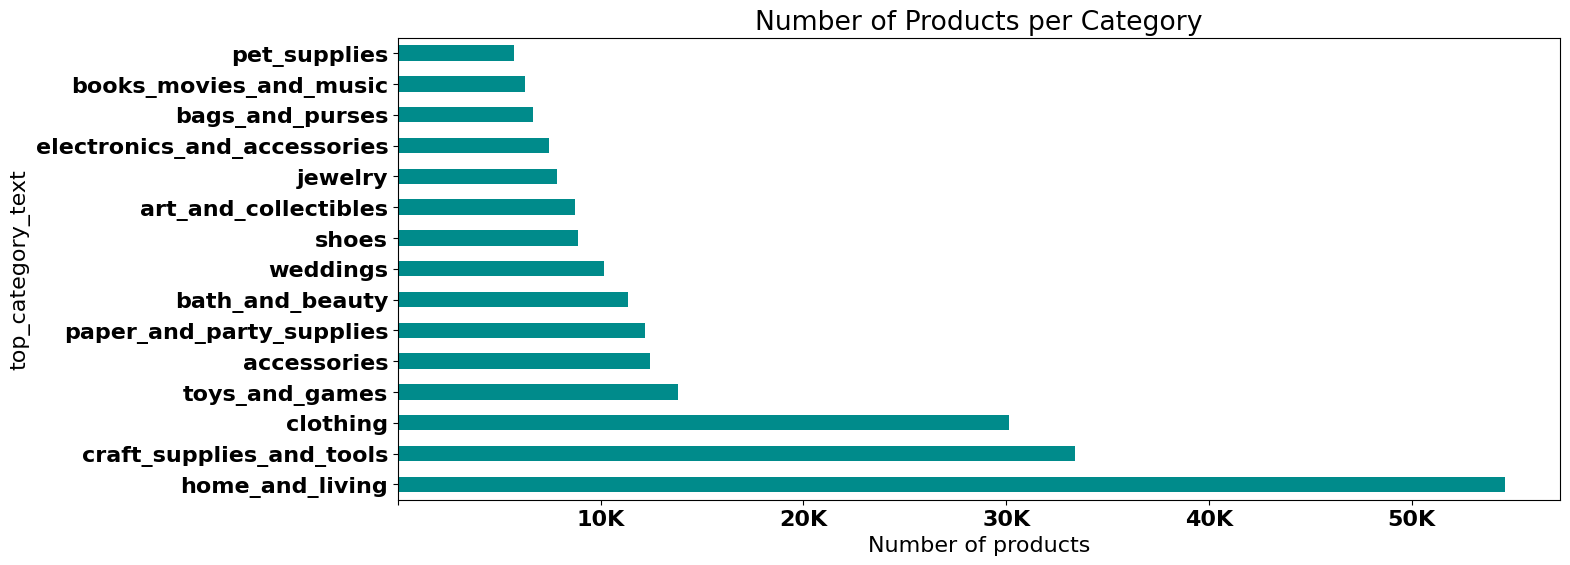

In [27]:
figsize = (15, 6)
column = 'top_category_text'
x_limit = 60000
x_step = 10000
color = 'darkcyan'

figure, ax = plt.subplots(figsize=figsize)
pd.value_counts(
    df_train[column],
    sort=True, ascending=False).plot.barh(color=color)
plt.title(f"Number of Products per Category")
xlabels = [f'{x // 1000:,}K' for x in range(0, x_limit, x_step)]
plt.xticks(range(0, x_limit, x_step), xlabels)
plt.xlabel('Number of products')
plt.setp(ax.get_xticklabels()[0], visible=False)
plt.show()

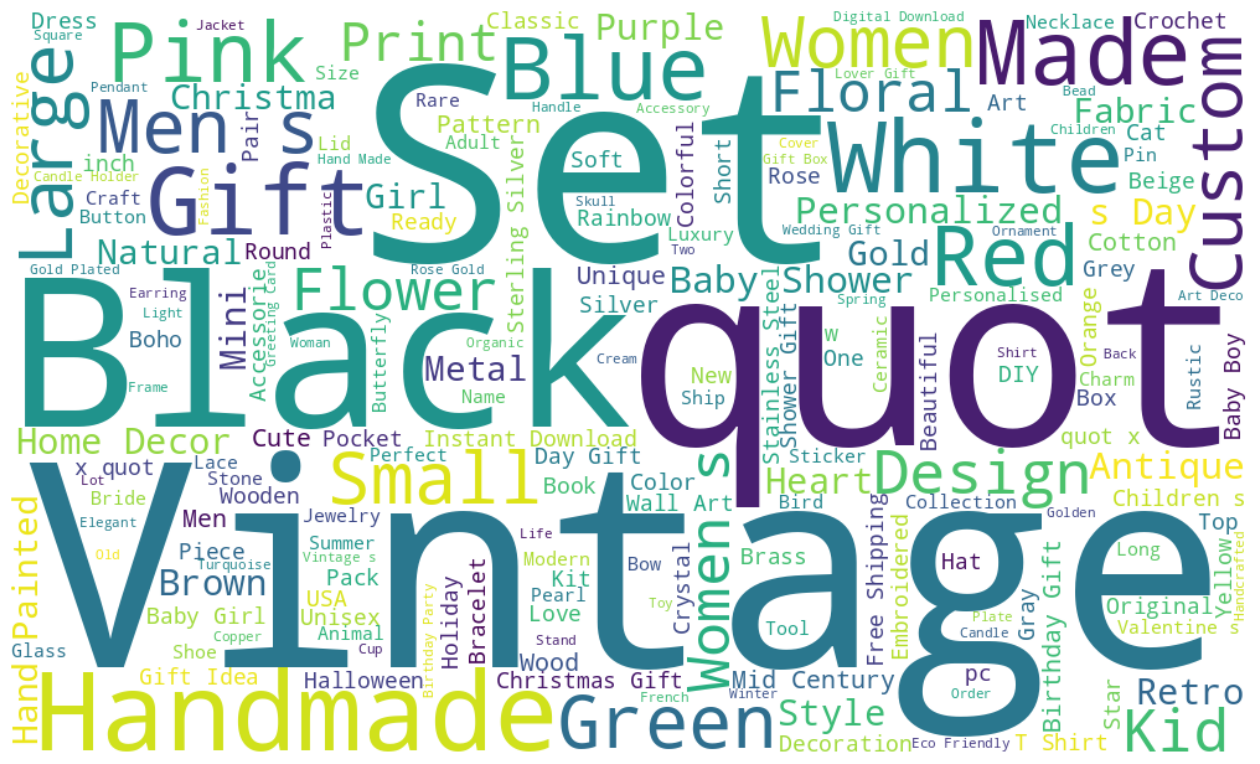

Number of frequent words: 200


In [58]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

text = " ".join(df_train['title'].astype(str).tolist())

# Creating a WordCloud object
wordcloud = WordCloud(width=1000, height=600, background_color='white', stopwords=STOPWORDS).generate(text)

plt.figure(figsize=(16, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

num_frequent_words = len(wordcloud.words_)

print("Number of frequent words:", num_frequent_words)

In [28]:
f"Number of bottom categories in train: {len(df_train['bottom_category_text'].unique()):,}"

'Number of bottom categories in train: 2,609'

### Test Dataset

The test dataset will be used to predict using the model/s you have trained

**Note** that categories and colors for the test data are hidden, you have to predict them!

In [11]:
df_test = read_data("test", parquet_filenames_test)

NameError: name 'parquet_filenames_test' is not defined

In [143]:
f'Number of rows in test: {len(df_test):,}'

'Number of rows in test: 25,514'

In [144]:
f"Number of unique products in test: {len(df_test['product_id'].unique()):,}"

'Number of unique products in test: 25,514'

In [145]:
f"Number of columns in test: {len(df_test.columns):,}"

'Number of columns in test: 15'

In [27]:
list(df_test.columns)

['product_id',
 'title',
 'description',
 'tags',
 'type',
 'room',
 'craft_type',
 'recipient',
 'material',
 'occasion',
 'holiday',
 'art_subject',
 'style',
 'shape',
 'pattern']

In [28]:
df_test.iloc[0]

,0
product_id,1305791780
title,Large Black And White Porcelain Pedestal Bowl
description,This is a beautiful porcelain pedestal bowl or...
tags,"pedestal bowl,porcelain punch bowl"
type,physical
room,
craft_type,
recipient,
material,ceramic
occasion,


## Model Training

Let's first split the data to be able to evaluate our model against a validation dataset. This validation set can also be used to fine tune your model before making the predictions on the hidden test set.

In [13]:
df_train.columns

Index(['product_id', 'title', 'description', 'tags', 'type', 'room',
       'craft_type', 'recipient', 'material', 'occasion', 'holiday',
       'art_subject', 'style', 'shape', 'pattern', 'bottom_category_id',
       'bottom_category_text', 'top_category_id', 'top_category_text',
       'primary_color_id', 'primary_color_text', 'secondary_color_id',
       'secondary_color_text'],
      dtype='object')

In [12]:
from sklearn.model_selection import train_test_split

df_train_1 = df_train.drop(['bottom_category_id',
       'bottom_category_text', 'top_category_id', 'top_category_text',
       'primary_color_id', 'primary_color_text', 'secondary_color_id',
       'secondary_color_text'],axis=True)
df_training, df_validation = train_test_split(
    df_train,
    test_size=0.1,
    stratify=df_train['bottom_category_text'],
    random_state=42)

In [32]:
df_training

,product_id,title,description,tags,type,room,craft_type,recipient,material,occasion,...,shape,pattern,bottom_category_id,bottom_category_text,top_category_id,top_category_text,primary_color_id,primary_color_text,secondary_color_id,secondary_color_text
859,880566017,New! Rust Palm Leaf Small Half Circle Earring ...,Rust Palm Leaf Leather Small Half Circles with...,"Leather Teardrops,Teardrop Shapes,Earring Maki...",physical,,leatherworking,,,,...,,,562,craft_supplies_and_tools,6,craft_supplies_and_tools,10,orange,7,gold
13,624988554,small green-yellow acetate glasses in aviation...,Material: Acetate\n\nColour: lime green-mustar...,,physical,,,,,,...,,,58,accessories.sunglasses_and_eyewear,0,accessories,9,green,9,green
1254,1602055547,2x Alfa Rome Emblems Stickers for Car Key Shel...,Specifications:\n\n\n\n\nMaterial: Crystal\n\n...,,physical,,,,,,...,,,12422,electronics_and_accessories.car_parts_and_acce...,7,electronics_and_accessories,1,black,9,green
12,1478485615,GALARIAN ARTICUNO V Chilling Reign 170/198 Cus...,GALARIAN ARTICUNO V Chilling Reign 170/198 Cus...,"Pokemon,TCG,Pokemon Card,Display Case,Pokeminh...",physical,,framing,,,,...,,,6675,craft_supplies_and_tools.storage_and_organizat...,6,craft_supplies_and_tools,12,purple,2,blue
1360,802998852,US Navy NWU III face mask. Ready to ship.,NWU type III face mask. Official Military prin...,"ripstop,USN,NWU TYPE III,US NAVY,Navy uniform,...",physical,,,,,,...,,,12112,bath_and_beauty.personal_care.face_masks_and_c...,3,bath_and_beauty,9,green,1,black
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2381,1548432398,Vintage Red Tin Spice Canister w Rack | Set of 5,Great Find. Hanging tin spice rack with 5 can...,"spice rack,tin spice rack,red spice rack,metal...",physical,,,,,,...,,,1079,home_and_living.kitchen_and_dining.kitchen_sto...,8,home_and_living,17,white,14,red
198,1150451491,Best Day Ever • Wedding Dinner Favors and Silv...,BEST DAY EVER. \n\nCelebrate your best day wit...,"bride to be,rehearsal dinner,wedding favors,we...",physical,,,,,,...,,,2820,weddings.decorations.serving_and_dining.weddin...,14,weddings,17,white,1,black
1570,1239056077,I&#39;m TWO SWEET | Boy Birthday Tee | Gifts u...,Celebrate birthdays with this short sleeved 10...,"baby shower,shower gifts,cheap gift,unique bab...",physical,,,,,,...,,,374,clothing,5,clothing,17,white,2,blue
1033,1608765597,NEW HAND CRAFTED Western Red Cedar Planter (Ha...,"Western Red Cedar Planter, made from reclaimed...","Cedar,Christmas,Present,Plants,Garden,Wooden,P...",physical,,,,,,...,,,6061,home_and_living.outdoor_and_garden.planters_an...,8,home_and_living,4,brown,4,brown


In [33]:
f"Number of products for training: {len(df_training):,}"

'Number of products for training: 206,661'

In [34]:
f"Number of products for validation: {len(df_validation):,}"

'Number of products for validation: 22,963'

In [16]:
df_train['top_category_text'].value_counts()

,count
top_category_text,
home_and_living,54600
craft_supplies_and_tools,33393
clothing,30143
toys_and_games,13835
accessories,12416
paper_and_party_supplies,12207
bath_and_beauty,11327
weddings,10143
shoes,8892


In [18]:
df_validation['bottom_category_text'].value_counts()

,count
bottom_category_text,
clothing.girls_clothing.underwear.panties,10
craft_supplies_and_tools.paints_inks_and_dyes.paint.chalk_paint,10
clothing.girls_clothing.baby_girls_clothing.sweaters,10
craft_supplies_and_tools.storage_and_organization.containers.bottles_cans_and_jars.lids_rings_and_caps.bottle_caps,10
paper_and_party_supplies.party_supplies.party_decor.party_candles,10
...,...
home_and_living.furniture.entryway_furniture.standing_coat_racks,4
jewelry.earrings.kaan_chains,4
craft_supplies_and_tools.doll_and_model_supplies.noise_makers,4


In [19]:
df_training['top_category_text'].value_counts()

,count
top_category_text,
home_and_living,49140
craft_supplies_and_tools,30056
clothing,27139
toys_and_games,12448
accessories,11173
paper_and_party_supplies,10984
bath_and_beauty,10187
weddings,9128
shoes,8001


In [37]:
df_validation['top_category_text'].value_counts()

,count
top_category_text,
home_and_living,5460
craft_supplies_and_tools,3337
clothing,3004
toys_and_games,1387
accessories,1243
paper_and_party_supplies,1223
bath_and_beauty,1140
weddings,1015
shoes,891


### Training

As a simple example, let's follow the [Working With Text Data](https://scikit-learn.org/stable/tutorial/text_analytics/working_with_text_data.html) tutorial from scikit-learn that:

- processes the text using `CountVectorizer`, that builds a dictionary of features and transforms documents to feature vectors
- extracts term frequencies and inverse document frequencies using `TfidfTransformer`, (see [TF-IDF](https://en.wikipedia.org/wiki/Tf%E2%80%93idf))
- trains a naïve Bayes classifier, which gives us a nice baseline

In [14]:
train_labels = df_training['top_category_id'].values

In [15]:
train_labels2 = df_training['bottom_category_id'].values

In [16]:
df_train_actual = df_training.drop(['top_category_text','bottom_category_text','top_category_id','bottom_category_id','primary_color_text','primary_color_id','secondary_color_id','secondary_color_text'],axis=True)

In [17]:
df_train_actual.columns

Index(['product_id', 'title', 'description', 'tags', 'type', 'room',
       'craft_type', 'recipient', 'material', 'occasion', 'holiday',
       'art_subject', 'style', 'shape', 'pattern'],
      dtype='object')

In [18]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

def preprocess_text(text):
    text = text.lower()

    # Removing punctuation and special characters
    text = re.sub(r'[^\w\s]', '', text)
    tokens = nltk.word_tokenize(text)

    # Stop word removal
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words]

    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    preprocessed_text = ' '.join(tokens)

    return preprocessed_text

df_train_actual['preprocessed_title'] = df_train_actual['title'].apply(preprocess_text)


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [19]:
# Step 1: Import Dependencies
import pandas as pd
import numpy as np
from category_encoders import OrdinalEncoder
from sklearn.feature_selection import chi2
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from scipy.sparse import hstack
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)  # Suppress warnings

# Step 2: Converting Text Features Using TF-IDF
vectorizer = TfidfVectorizer()
X_text = vectorizer.fit_transform(df_train_actual['preprocessed_title'].fillna(''))

# Step 3: Applying Ordinal Encoding to Categorical Features
categorical_cols = ['type', 'room', 'craft_type', 'recipient',
                    'material', 'occasion', 'holiday', 'art_subject',
                    'style', 'shape', 'pattern']

df_train_actual[categorical_cols] = df_train_actual[categorical_cols].astype(str)
encoder = OrdinalEncoder()
X_categorical = encoder.fit_transform(df_train_actual[categorical_cols])


# Step 4: Applying Chi-Squared Feature Selection to TF-IDF Features
chi2_scores, p_values = chi2(X_text, train_labels)
num_features_to_select = 3000
k_best_features = np.argsort(chi2_scores)[-num_features_to_select:]
X_selected = X_text[:, k_best_features]

# Step 6: Combining All Features
X_final = hstack([X_selected, X_categorical])
y_train_top = train_labels
y_train_bottom = train_labels2





In [ ]:
#  Training Logistic Regression for top_category_id
X_train_top, X_val_top, y_train_top, y_val_top = train_test_split(X_final, y_train_top, test_size=0.2)
model_top = LogisticRegression(solver='liblinear')
model_top.fit(X_train_top, y_train_top)
y_pred_top = model_top.predict(X_val_top)
accuracy_top = accuracy_score(y_val_top, y_pred_top)
f1_top = f1_score(y_val_top, y_pred_top, average='weighted')

print("Top Category Prediction:")
print(f"Validation Accuracy: {accuracy_top:.4f}, F1 Score: {f1_top:.4f}")

In [ ]:
# Random Forest classifier for Bottom Category (Handles large class counts better)
from sklearn.ensemble import RandomForestClassifier

X_train_bottom, X_val_bottom, y_train_bottom, y_val_bottom = train_test_split(X_final, y_train_bottom, test_size=0.2, random_state=42)
model_bottom = RandomForestClassifier(n_estimators=300, max_depth=15, class_weight="balanced", random_state=42)
model_bottom.fit(X_train_bottom, y_train_bottom)
y_pred_bottom = model_bottom.predict(X_val_bottom)

accuracy_bottom = accuracy_score(y_val_bottom, y_pred_bottom)
f1_bottom = f1_score(y_val_bottom, y_pred_bottom, average='weighted')

print("Bottom Category Prediction:")
print(f"Validation Accuracy: {accuracy_bottom:.4f}, F1 Score: {f1_bottom:.4f}")


### Evaluation

Using our validation dataset, compute a number of metrics to measure how well we generalize on our validation set.

In [29]:
df_validation['preprocessed_title'] = df_validation['title'].apply(preprocess_text)
df_validation[categorical_cols] = df_validation[categorical_cols].astype(str)
X_validation_categorical = encoder.transform(df_validation[categorical_cols])
X_validation_text = vectorizer.transform(df_validation['preprocessed_title'].fillna(''))
X_validation_selected = X_validation_text[:, k_best_features]
X_validation_final = hstack([X_validation_selected, X_validation_categorical])

y_pred_validation_top = model_top.predict(X_validation_final)
y_pred_validation_bottom = model_bottom.predict(X_validation_final)

y_actual_top = df_validation['top_category_id']
y_actual_bottom = df_validation['bottom_category_id']

accuracy_validation_top = accuracy_score(y_actual_top, y_pred_validation_top)
f1_validation_top = f1_score(y_actual_top, y_pred_validation_top, average='weighted')

accuracy_validation_bottom = accuracy_score(y_actual_bottom, y_pred_validation_bottom)
f1_validation_bottom = f1_score(y_actual_bottom, y_pred_validation_bottom, average='weighted')

print("\nValidation Results:")
print(f"Top Category Accuracy: {accuracy_validation_top:.4f}, F1 Score: {f1_validation_top:.4f}")
print(metrics.classification_report(y_actual_top,y_pred_validation_top))
print(f"Bottom Category Accuracy: {accuracy_validation_bottom:.4f}, F1 Score: {f1_validation_bottom:.4f}")
print(metrics.classification_report(y_actual_bottom,y_pred_validation_bottom))


Validation Results:
Top Category Accuracy: 0.8056, F1 Score: 0.8021


**Note** that this is just a baseline that uses a naïve Bayes classifier and uses the `title` only as inputs, there are many more parameters that can be used in addition to multiple architectures and processing approaches